# Benchmarking RealSense + YOLO11 Jetson Nano
## Analyse des performances TCP, CPU, Latence et métriques d'inférence

Ce notebook teste les performances du streaming vidéo temps réel entre Jetson Nano et PC Windows via TCP.
- Mesure la latence réseau, débit, perte de frames
- Analyse CPU/MEM pendant l'inférence YOLO11
- Teste différentes configurations ONNX Runtime
- Compare l'impact de JPEG_QUALITY et FRAME_STRIDE


In [ ]:
import socket
import struct
import pickle
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from datetime import datetime
from collections import deque
import threading
import paramiko
from pathlib import Path

print(" Benchmarking RealSense + YOLO11 Jetson Nano")
print("=" * 70)

# Jetson configuration (USB connection)
JETSON_HOST = "192.168.55.1"
JETSON_USER = "jetson"
JETSON_PASSWORD = "jetson"
JETSON_SSH_KEY = None
SERVER_PATH = "/home/jetson/realsense_yolo_project/scripts/realsense_server_jetson.py"
SERVER_PORT = 8485
SSH_TIMEOUT = 10

# TCP Protocol
PAYLOAD_HEADER_SIZE = 4  # 4 bytes network-order unsigned int

# Benchmark settings
BENCHMARK_CONFIGS = [
    {
        "name": "Baseline (CPU only)",
        "env": {
            "INPUT_SIZE": "640",
            "JPEG_QUALITY": "80",
            "FRAME_STRIDE": "1",
            "DISABLE_MASKS": "0",
            "ORT_PROVIDERS": "CPUExecutionProvider"
        }
    },
    {
        "name": "CUDA optimized",
        "env": {
            "INPUT_SIZE": "640",
            "JPEG_QUALITY": "80",
            "FRAME_STRIDE": "1",
            "DISABLE_MASKS": "0",
            "ORT_PROVIDERS": "CUDAExecutionProvider,CPUExecutionProvider"
        }
    },
    {
        "name": "Reduced resolution (480)",
        "env": {
            "INPUT_SIZE": "480",
            "JPEG_QUALITY": "70",
            "FRAME_STRIDE": "1",
            "DISABLE_MASKS": "1",
            "ORT_PROVIDERS": "CUDAExecutionProvider,CPUExecutionProvider"
        }
    },
    {
        "name": "Frame stride 2 (half FPS)",
        "env": {
            "INPUT_SIZE": "640",
            "JPEG_QUALITY": "80",
            "FRAME_STRIDE": "2",
            "DISABLE_MASKS": "0",
            "ORT_PROVIDERS": "CUDAExecutionProvider,CPUExecutionProvider"
        }
    },
]

BENCHMARK_DURATION = 60  # seconds
METRICS_DIR = Path("benchmark_results")
METRICS_DIR.mkdir(exist_ok=True)

print(f"\n✓ Configuration chargée")
print(f"  Jetson: {JETSON_HOST}:{SERVER_PORT} (USB)")
print(f"  Benchmarks: {len(BENCHMARK_CONFIGS)} configurations")
print(f"  Durée: {BENCHMARK_DURATION}s par test")

📊 Benchmarking RealSense + YOLO11 Jetson Nano

✓ Configuration chargée
  Jetson: 192.168.55.1:8485 (USB)
  Benchmarks: 4 configurations
  Durée: 60s par test


## 🔧 Configuration avancée : Tester différents modèles et optimisations

In [22]:
# 🎯 GUIDE : Tester différents modèles et optimisations

print("""
═══════════════════════════════════════════════════════════════════════
  COMMENT TESTER DIFFÉRENTS MODÈLES ET OPTIMISATIONS ?
═══════════════════════════════════════════════════════════════════════

📦 1. TESTER DIFFÉRENTS MODÈLES YOLO
────────────────────────────────────────────────────────────────────────
Sur la Jetson, placez vos modèles dans le même dossier que le serveur:
  - yolo11n-seg.onnx          (nano - plus rapide)
  - yolo11s-seg.onnx          (small - équilibré)
  - yolo11m-seg.onnx          (medium - plus précis)
  - yolo11n-seg.optimized.onnx (nano optimisé)

Puis modifiez la variable MODEL_PATH_FORCE dans les configs ci-dessous.

⚙️ 2. OPTIMISATIONS ONNX RUNTIME DISPONIBLES
────────────────────────────────────────────────────────────────────────
a) CPU Optimizations:
   - CPUExecutionProvider (baseline)
   - Avec Graph Optimization Level

b) CUDA Optimizations:
   - CUDAExecutionProvider
   - Arena memory management
   - cudNN algorithm search

c) TensorRT Optimizations:
   - TensorrtExecutionProvider
   - FP16 precision (plus rapide, légère perte précision)
   - INT8 quantization (le plus rapide, calibration requise)
   - Engine caching (réutilise les modèles compilés)

🔬 3. OPTIMISATIONS DU MODÈLE (AVANT LE BENCHMARK)
────────────────────────────────────────────────────────────────────────
a) Réduire la résolution d'entrée:
   INPUT_SIZE: 640 → 480 → 320 (trade-off vitesse/précision)

b) Désactiver les masques de segmentation:
   DISABLE_MASKS: "1" (gain de performance significatif)

c) Frame skipping:
   FRAME_STRIDE: 2 ou 3 (traiter 1 frame sur N)

d) Compression JPEG:
   JPEG_QUALITY: 50-90 (trade-off bande passante/qualité)

💡 4. EXEMPLE : CRÉER DE NOUVELLES CONFIGURATIONS
────────────────────────────────────────────────────────────────────────
""")

# Configuration supplémentaire pour tester différents modèles
ADVANCED_BENCHMARK_CONFIGS = [
    {
        "name": "YOLOv11n - TensorRT FP16",
        "env": {
            "MODEL_PATH_FORCE": "/home/jetson/realsense_yolo_project/models/yolo11n-seg.onnx",
            "INPUT_SIZE": "640",
            "JPEG_QUALITY": "80",
            "FRAME_STRIDE": "1",
            "DISABLE_MASKS": "0",
            "ORT_PROVIDERS": "TensorrtExecutionProvider,CUDAExecutionProvider,CPUExecutionProvider",
            "ORT_TRT_FP16": "1",
            "ORT_TRT_INT8": "0"
        }
    },
    {
        "name": "YOLOv11n - TensorRT INT8",
        "env": {
            "MODEL_PATH_FORCE": "/home/jetson/yolo11n-seg.onnx",
            "INPUT_SIZE": "640",
            "JPEG_QUALITY": "80",
            "FRAME_STRIDE": "1",
            "DISABLE_MASKS": "0",
            "ORT_PROVIDERS": "TensorrtExecutionProvider,CUDAExecutionProvider,CPUExecutionProvider",
            "ORT_TRT_FP16": "0",
            "ORT_TRT_INT8": "1"  # Plus rapide mais nécessite calibration
        }
    },
    {
        "name": "YOLOv11s - CUDA",
        "env": {
            "MODEL_PATH_FORCE": "/home/jetson/yolo11s-seg.onnx",  # Modèle small
            "INPUT_SIZE": "640",
            "JPEG_QUALITY": "80",
            "FRAME_STRIDE": "1",
            "DISABLE_MASKS": "0",
            "ORT_PROVIDERS": "CUDAExecutionProvider,CPUExecutionProvider"
        }
    },
    {
        "name": "YOLOv11n optimized - Résolution 320",
        "env": {
            "MODEL_PATH_FORCE": "/home/jetson/yolo11n-seg.optimized.onnx",
            "INPUT_SIZE": "320",  # Résolution très basse = très rapide
            "JPEG_QUALITY": "70",
            "FRAME_STRIDE": "1",
            "DISABLE_MASKS": "1",  # Pas de masques = gain perf
            "ORT_PROVIDERS": "CUDAExecutionProvider,CPUExecutionProvider"
        }
    },
    {
        "name": "YOLOv11n - Ultra Low Latency",
        "env": {
            "MODEL_PATH_FORCE": "/home/jetson/yolo11n-seg.optimized.onnx",
            "INPUT_SIZE": "416",
            "JPEG_QUALITY": "60",  # Compression maximale
            "FRAME_STRIDE": "2",   # 1 frame sur 2
            "DISABLE_MASKS": "1",  # Pas de masques
            "ORT_PROVIDERS": "TensorrtExecutionProvider,CUDAExecutionProvider,CPUExecutionProvider",
            "ORT_TRT_FP16": "1"
        }
    }
]

print(f"\n✅ {len(ADVANCED_BENCHMARK_CONFIGS)} configurations avancées définies")
print("""
📝 POUR UTILISER CES CONFIGURATIONS:

1. Remplacez BENCHMARK_CONFIGS par ADVANCED_BENCHMARK_CONFIGS:
   
   # Dans la cellule de configuration (cellule 2), remplacez:
   BENCHMARK_CONFIGS = ADVANCED_BENCHMARK_CONFIGS
   
   # Ou fusionnez les deux:
   BENCHMARK_CONFIGS.extend(ADVANCED_BENCHMARK_CONFIGS)

2. Lancez les benchmarks normalement avec run_all_benchmarks()

3. Comparez les résultats avec plot_latency_analysis()

⚠️  IMPORTANT:
   - Assurez-vous que les modèles existent sur la Jetson
   - TensorRT INT8 nécessite une calibration préalable
   - Les chemins MODEL_PATH_FORCE doivent être absolus
   
🔗 POUR OPTIMISER VOS MODÈLES ONNX:
   Utilisez les scripts dans Autonomous_intelligent_systems/src/AI-Optimizations/
   - optimize_with_onnxsim.py : Simplification du graphe
   - optimize_onnxruntime.py : Optimisations ONNX Runtime
""")


═══════════════════════════════════════════════════════════════════════
  COMMENT TESTER DIFFÉRENTS MODÈLES ET OPTIMISATIONS ?
═══════════════════════════════════════════════════════════════════════

📦 1. TESTER DIFFÉRENTS MODÈLES YOLO
────────────────────────────────────────────────────────────────────────
Sur la Jetson, placez vos modèles dans le même dossier que le serveur:
  - yolo11n-seg.onnx          (nano - plus rapide)
  - yolo11s-seg.onnx          (small - équilibré)
  - yolo11m-seg.onnx          (medium - plus précis)
  - yolo11n-seg.optimized.onnx (nano optimisé)

Puis modifiez la variable MODEL_PATH_FORCE dans les configs ci-dessous.

⚙️ 2. OPTIMISATIONS ONNX RUNTIME DISPONIBLES
────────────────────────────────────────────────────────────────────────
a) CPU Optimizations:
   - CPUExecutionProvider (baseline)
   - Avec Graph Optimization Level

b) CUDA Optimizations:
   - CUDAExecutionProvider
   - Arena memory management
   - cudNN algorithm search

c) TensorRT Optimizatio

## 🧪 Test rapide : Comparer 2 configurations

In [ ]:
# 🔬 Exemple : Comparer CPU vs TensorRT FP16 sur le même modèle

# Définir 2 configs à comparer
comparison_configs = [
    {
        "name": "Baseline CPU",
        "env": {
            "INPUT_SIZE": "640",
            "JPEG_QUALITY": "80",
            "FRAME_STRIDE": "1",
            "DISABLE_MASKS": "0",
            "ORT_PROVIDERS": "CPUExecutionProvider"
        }
    },
    {
        "name": "TensorRT FP16",
        "env": {
            "INPUT_SIZE": "640",
            "JPEG_QUALITY": "80",
            "FRAME_STRIDE": "1",
            "DISABLE_MASKS": "0",
            "ORT_PROVIDERS": "TensorrtExecutionProvider,CUDAExecutionProvider,CPUExecutionProvider",
            "ORT_TRT_FP16": "1"
        }
    }
]

# Fonction pour comparer rapidement 2 configs
def compare_two_configs(config1, config2, duration=30):
    """Comparer 2 configurations rapidement"""
    
    print(f"\n{'='*70}")
    print(f"  COMPARAISON RAPIDE : {config1['name']} vs {config2['name']}")
    print(f"{'='*70}\n")
    
    results = []
    
    # Test config 1
    temp_configs = [config1]
    old_configs = BENCHMARK_CONFIGS.copy()
    globals()['BENCHMARK_CONFIGS'] = temp_configs
    
    print(f"\n🔵 Test 1/2 : {config1['name']}")
    result1 = run_benchmark(0, duration)
    if result1:
        results.append(result1)
    
    # Pause
    print(f"\nPause 10s...")
    time.sleep(10)
    
    # Test config 2
    globals()['BENCHMARK_CONFIGS'] = [config2]
    print(f"\n Test 2/2 : {config2['name']}")
    result2 = run_benchmark(0, duration)
    if result2:
        results.append(result2)
    
    # Restaurer
    globals()['BENCHMARK_CONFIGS'] = old_configs
    
    # Afficher résultats
    if len(results) == 2:
        print(f"\n\n{'='*70}")
        print(f"  RÉSULTATS DE LA COMPARAISON")
        print(f"{'='*70}\n")
        
        metrics1 = results[0]['tcp_metrics']
        metrics2 = results[1]['tcp_metrics']
        
        print(f"{'Métrique':<25} {config1['name']:<20} {config2['name']:<20} {'Gain':<10}")
        print(f"{'='*80}")
        
        fps_gain = ((metrics2['fps'] - metrics1['fps']) / metrics1['fps'] * 100) if metrics1['fps'] > 0 else 0
        print(f"{'FPS':<25} {metrics1['fps']:<20.1f} {metrics2['fps']:<20.1f} {fps_gain:+.1f}%")
        
        lat_gain = ((metrics1['latency_mean_ms'] - metrics2['latency_mean_ms']) / metrics1['latency_mean_ms'] * 100) if metrics1['latency_mean_ms'] > 0 else 0
        print(f"{'Latence (ms)':<25} {metrics1['latency_mean_ms']:<20.2f} {metrics2['latency_mean_ms']:<20.2f} {lat_gain:+.1f}%")
        
        tp_gain = ((metrics2['throughput_mbps'] - metrics1['throughput_mbps']) / metrics1['throughput_mbps'] * 100) if metrics1['throughput_mbps'] > 0 else 0
        print(f"{'Débit (Mbps)':<25} {metrics1['throughput_mbps']:<20.2f} {metrics2['throughput_mbps']:<20.2f} {tp_gain:+.1f}%")
        
        print(f"{'='*80}\n")
        
        # Graphique comparatif
        tcp_metrics = [r['tcp_metrics'] for r in results]
        config_names = [r['config']['name'] for r in results]
        plot_latency_analysis(tcp_metrics, config_names)
        
        # Métriques serveur
        for r in results:
            if r['csv_file']:
                plot_server_metrics(r['csv_file'], r['config']['name'])
    
    return results

print("""
Fonction compare_two_configs() prête

UTILISATION:
   # Comparer les 2 configs définies ci-dessus (30 secondes chacune)
   results = compare_two_configs(comparison_configs[0], comparison_configs[1], 30)
   
   # Ou créer vos propres configs:
   config_a = {"name": "Test A", "env": {...}}
   config_b = {"name": "Test B", "env": {...}}
   results = compare_two_configs(config_a, config_b, 45)
""")


✅ Fonction compare_two_configs() prête

📝 UTILISATION:
   # Comparer les 2 configs définies ci-dessus (30 secondes chacune)
   results = compare_two_configs(comparison_configs[0], comparison_configs[1], 30)
   
   # Ou créer vos propres configs:
   config_a = {"name": "Test A", "env": {...}}
   config_b = {"name": "Test B", "env": {...}}
   results = compare_two_configs(config_a, config_b, 45)



## Étape 1 : Connexion SSH à Jetson


In [24]:
class JetsonSSHManager:
    """Gère la connexion SSH vers la Jetson avec keep-alive"""
    
    def __init__(self, host, user, password=None, ssh_key=None, timeout=5):
        self.host = host
        self.user = user
        self.password = password
        self.ssh_key = ssh_key
        self.timeout = timeout
        self.ssh_client = None
        self.is_connected = False
    
    def connect(self):
        """Établir la connexion SSH"""
        self.ssh_client = paramiko.SSHClient()
        self.ssh_client.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        
        try:
            print(f"📡 Connexion SSH: {self.host}:22...")
            self.ssh_client.connect(
                self.host,
                username=self.user,
                password=self.password,
                key_filename=self.ssh_key,
                timeout=self.timeout,
                banner_timeout=self.timeout,
                look_for_keys=False,
                allow_agent=False
            )
            
            # Activer le keep-alive
            transport = self.ssh_client.get_transport()
            if transport:
                transport.set_keepalive(60)
            
            self.is_connected = True
            print(f"✓ SSH connecté (keep-alive: 60s)")
            return True
        except Exception as e:
            print(f"✗ Erreur SSH: {e}")
            self.is_connected = False
            return False
    
    def is_active(self):
        """Vérifier si la connexion est active"""
        if not self.ssh_client:
            return False
        try:
            transport = self.ssh_client.get_transport()
            return transport and transport.is_active()
        except:
            return False
    
    def execute_command(self, command, timeout=None):
        """Exécuter une commande SSH"""
        if not self.ssh_client:
            return None, None, None
        try:
            return self.ssh_client.exec_command(command, timeout=timeout or self.timeout)
        except Exception as e:
            print(f"✗ Erreur exécution: {e}")
            return None, None, None
    
    def disconnect(self):
        """Fermer la connexion SSH"""
        if self.ssh_client:
            self.ssh_client.close()
            self.is_connected = False
            print("✓ SSH déconnecté")

# Connexion
ssh_manager = JetsonSSHManager(JETSON_HOST, JETSON_USER, JETSON_PASSWORD, JETSON_SSH_KEY, SSH_TIMEOUT)
if ssh_manager.connect():
    print("\n✅ Prêt pour benchmark")
else:
    print("\n❌ Erreur connexion. Vérifiez:")
    print("   1. Jetson allumée, connectée via USB")
    print("   2. SSH activé sur Jetson")
    print("   3. IP correcte (192.168.55.1 ou 192.168.0.100)")

📡 Connexion SSH: 192.168.55.1:22...
✓ SSH connecté (keep-alive: 60s)

✅ Prêt pour benchmark


## Étape 2 : Client TCP avec collecte de métriques réseau et système


In [ ]:
class MetricCollector:
    """Collecte les métriques TCP et système en temps réel"""
    
    def __init__(self):
        self.frames_received = 0
        self.bytes_received = 0
        self.start_time = None
        self.latencies = deque(maxlen=10000)  # historique des latences
        self.payload_sizes = deque(maxlen=10000)
        self.frame_times = deque(maxlen=10000)
        self.timestamps = deque(maxlen=10000)
        self.lock = threading.Lock()
    
    def add_frame(self, payload_size, received_time):
        """Enregistrer une frame reçue"""
        with self.lock:
            self.frames_received += 1
            self.bytes_received += payload_size + PAYLOAD_HEADER_SIZE
            self.payload_sizes.append(payload_size)
            self.timestamps.append(received_time)
            
            if len(self.frame_times) > 0:
                latency = received_time - self.frame_times[-1]
                self.latencies.append(latency)
            
            self.frame_times.append(received_time)
    
    def get_stats(self):
        """Retourner les statistiques actuelles"""
        with self.lock:
            # Valeurs par défaut si aucune donnée
            if self.frames_received == 0:
                return {
                    'frames_total': 0,
                    'bytes_total_mb': 0,
                    'elapsed_s': 0,
                    'throughput_mbps': 0,
                    'latency_min_ms': 0,
                    'latency_max_ms': 0,
                    'latency_mean_ms': 0,
                    'latency_p50_ms': 0,
                    'latency_p90_ms': 0,
                    'latency_p99_ms': 0,
                    'payload_mean_kb': 0,
                    'fps': 0,
                }
            
            elapsed = self.frame_times[-1] - self.frame_times[0] if len(self.frame_times) > 1 else 1
            
            # Si pas de latencies (1 seule frame), retourner stats partielles
            if not self.latencies:
                return {
                    'frames_total': self.frames_received,
                    'bytes_total_mb': self.bytes_received / (1024*1024),
                    'elapsed_s': elapsed,
                    'throughput_mbps': (self.bytes_received * 8) / (elapsed * 1e6) if elapsed > 0 else 0,
                    'latency_min_ms': 0,
                    'latency_max_ms': 0,
                    'latency_mean_ms': 0,
                    'latency_p50_ms': 0,
                    'latency_p90_ms': 0,
                    'latency_p99_ms': 0,
                    'payload_mean_kb': np.array(list(self.payload_sizes)).mean() / 1024 if self.payload_sizes else 0,
                    'fps': self.frames_received / elapsed if elapsed > 0 else 0,
                }
            
            latencies_ms = np.array(list(self.latencies)) * 1000
            sizes_kb = np.array(list(self.payload_sizes)) / 1024
            
            return {
                'frames_total': self.frames_received,
                'bytes_total_mb': self.bytes_received / (1024*1024),
                'elapsed_s': elapsed,
                'throughput_mbps': (self.bytes_received * 8) / (elapsed * 1e6) if elapsed > 0 else 0,
                'latency_min_ms': latencies_ms.min(),
                'latency_max_ms': latencies_ms.max(),
                'latency_mean_ms': latencies_ms.mean(),
                'latency_p50_ms': np.percentile(latencies_ms, 50),
                'latency_p90_ms': np.percentile(latencies_ms, 90),
                'latency_p99_ms': np.percentile(latencies_ms, 99),
                'payload_mean_kb': sizes_kb.mean(),
                'fps': self.frames_received / elapsed if elapsed > 0 else 0,
            }

class TCPStreamClient:
    """Client TCP pour le streaming du serveur Jetson"""
    
    def __init__(self, host, port, timeout=30):
        self.host = host
        self.port = port
        self.timeout = timeout
        self.socket = None
        self.connected = False
        self.metrics = MetricCollector()
        self._stop = False
    
    def connect(self):
        """Connecter au serveur"""
        try:
            print(f"🔌 Connexion TCP: {self.host}:{self.port}...")
            self.socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
            self.socket.settimeout(self.timeout)
            self.socket.connect((self.host, self.port))
            self.connected = True
            self.metrics.start_time = time.time()
            print(f"✓ TCP connecté")
            return True
        except Exception as e:
            print(f"✗ Erreur TCP: {e}")
            return False
    
    def receive_frames_for_duration(self, duration):
        """Recevoir les frames pendant une durée donnée"""
        print(f"\nRéception pendant {duration}s...\n")
        start_time = time.time()
        data_buffer = b""
        last_stats = 0
        
        try:
            while time.time() - start_time < duration:
                # Recevoir les données
                try:
                    chunk = self.socket.recv(8192)
                except socket.timeout:
                    continue
                
                if not chunk:
                    print("Connexion fermée par serveur")
                    break
                
                data_buffer += chunk
                
                # Extraire les frames du buffer
                while len(data_buffer) >= PAYLOAD_HEADER_SIZE:
                    # Lire l'en-tête (taille du payload)
                    header = data_buffer[:PAYLOAD_HEADER_SIZE]
                    payload_size = struct.unpack('!I', header)[0]
                    
                    # Vérifier si on a le payload complet
                    if len(data_buffer) < PAYLOAD_HEADER_SIZE + payload_size:
                        break
                    
                    # Extraire le payload
                    payload = data_buffer[PAYLOAD_HEADER_SIZE:PAYLOAD_HEADER_SIZE + payload_size]
                    data_buffer = data_buffer[PAYLOAD_HEADER_SIZE + payload_size:]
                    
                    # Enregistrer les métriques
                    self.metrics.add_frame(payload_size, time.time())
                
                # Afficher la progression
                elapsed = time.time() - start_time
                if elapsed - last_stats >= 5:
                    stats = self.metrics.get_stats()
                    if stats and stats['frames_total'] > 0:
                        print(f"  ✓ {stats['frames_total']:3d} frames | "
                              f"FPS: {stats['fps']:5.1f} | "
                              f"Latence: {stats['latency_mean_ms']:6.2f}ms (p90: {stats['latency_p90_ms']:6.2f}ms) | "
                              f"Débit: {stats['throughput_mbps']:6.2f} Mbps")
                    last_stats = elapsed
        
        except KeyboardInterrupt:
            print("Arrêt utilisateur")
        
        return self.metrics
    
    def disconnect(self):
        """Fermer la connexion"""
        if self.socket:
            self.socket.close()
            self.connected = False
            print("✓ TCP déconnecté")

print("✓ Classes TCP et métriques définies")

✓ Classes TCP et métriques définies


## Étape 3 : Exécution du benchmark


In [ ]:
def run_benchmark(config_index=0, duration=None):
    """Exécuter un benchmark complet"""
    
    if not ssh_manager.is_active():
        print("❌ SSH non actif, reconnexion...")
        if not ssh_manager.connect():
            return None
    
    config = BENCHMARK_CONFIGS[config_index]
    config_name = config["name"]
    test_duration = duration or BENCHMARK_DURATION
    
    print(f"\n{'='*70}")
    print(f"BENCHMARK: {config_name}")
    print(f"{'='*70}")
    
    # Fichier CSV pour cette config
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_filename = METRICS_DIR / f"metrics_{config_index}_{timestamp}.csv"
    remote_csv = f"/tmp/benchmark_{timestamp}.csv"
    
    # Construire la commande SSH
    env_vars = " ".join([f"{k}={v}" for k, v in config["env"].items()])
    server_cmd = (
        f"cd $(dirname {SERVER_PATH}) && "
        f"METRICS_CSV={remote_csv} {env_vars} "
        f"timeout {test_duration} python3 {SERVER_PATH} || true"
    )
    
    print(f"\n📋 Configuration d'environnement:")
    for k, v in config["env"].items():
        print(f"   {k}={v}")
    
    # Lancer le serveur
    print(f"\nLancement du serveur...")
    stdin, stdout, stderr = ssh_manager.execute_command(server_cmd, timeout=test_duration + 15)
    
    if not stdout:
        print("Erreur lancement serveur")
        return None
    
    # Attendre le démarrage du serveur
    print("Démarrage du serveur (2s)...")
    time.sleep(2)
    
    # Connecter le client TCP
    client = TCPStreamClient(JETSON_HOST, SERVER_PORT, timeout=test_duration + 10)
    
    if not client.connect():
        print("❌ Impossible de se connecter au serveur TCP")
        return None
    
    # Recevoir les frames
    metrics = client.receive_frames_for_duration(test_duration)
    client.disconnect()
    
    # Récupérer le CSV depuis Jetson
    print(f"\n📥 Récupération du fichier CSV...")
    try:
        sftp = ssh_manager.ssh_client.open_sftp()
        sftp.get(remote_csv, str(csv_filename))
        sftp.remove(remote_csv)
        sftp.close()
        print(f"✓ Sauvegardé: {csv_filename}")
    except Exception as e:
        print(f"⚠️ Erreur récupération CSV: {e}")
        csv_filename = None
    
    # Résumer les métriques TCP
    stats = metrics.get_stats()
    
    if stats['frames_total'] == 0:
        print(f"\n⚠️  Aucune frame reçue!")
        print(f"   Le serveur a peut-être eu un problème de démarrage")
        return None
    
    print(f"\nRésumé des métriques TCP:")
    print(f"   Frames: {stats['frames_total']}")
    print(f"   FPS: {stats['fps']:.1f}")
    print(f"   Latence moyenne: {stats['latency_mean_ms']:.2f}ms")
    print(f"   Latence p90: {stats['latency_p90_ms']:.2f}ms")
    print(f"   Débit: {stats['throughput_mbps']:.2f} Mbps")
    
    return {
        'config': config,
        'csv_file': csv_filename,
        'tcp_metrics': stats
    }

print("\n✓ Fonction run_benchmark() prête")


✓ Fonction run_benchmark() prête


## Étape 4 : Analyse des métriques de latence TCP


In [27]:
def plot_latency_analysis(metrics_list, config_names):
    """Analyser et afficher les latences TCP"""
    if not metrics_list:
        print("Pas de données à analyser")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Analyse de la Latence TCP", fontsize=16, fontweight='bold')
    
    # 1. Comparaison des latences moyennes
    ax = axes[0, 0]
    means = [m['latency_mean_ms'] for m in metrics_list]
    p90s = [m['latency_p90_ms'] for m in metrics_list]
    x = np.arange(len(config_names))
    ax.bar(x - 0.2, means, 0.4, label='Moyenne', color='#2E86AB')
    ax.bar(x + 0.2, p90s, 0.4, label='p90', color='#A23B72')
    ax.set_ylabel('Latence (ms)')
    ax.set_title('Latence Moyenne vs P90')
    ax.set_xticks(x)
    ax.set_xticklabels(config_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. Distribution percentiles
    ax = axes[0, 1]
    percentiles = ['min', 'p50', 'p90', 'p99', 'max']
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(config_names)))
    
    for i, (metrics, name, color) in enumerate(zip(metrics_list, config_names, colors)):
        values = [
            metrics['latency_min_ms'],
            metrics['latency_p50_ms'],
            metrics['latency_p90_ms'],
            metrics['latency_p99_ms'],
            metrics['latency_max_ms']
        ]
        ax.plot(percentiles, values, marker='o', label=name, color=color, linewidth=2)
    
    ax.set_ylabel('Latence (ms)')
    ax.set_title('Percentiles de Latence')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # 3. FPS et débit
    ax = axes[1, 0]
    fps_vals = [m['fps'] for m in metrics_list]
    throughput_vals = [m['throughput_mbps'] for m in metrics_list]
    ax2 = ax.twinx()
    
    bars1 = ax.bar(x - 0.2, fps_vals, 0.4, label='FPS', color='#F18F01')
    bars2 = ax2.bar(x + 0.2, throughput_vals, 0.4, label='Débit (Mbps)', color='#C73E1D')
    
    ax.set_ylabel('FPS', color='#F18F01')
    ax2.set_ylabel('Débit (Mbps)', color='#C73E1D')
    ax.set_title('FPS et Débit')
    ax.set_xticks(x)
    ax.set_xticklabels(config_names, rotation=45, ha='right')
    ax.tick_params(axis='y', labelcolor='#F18F01')
    ax2.tick_params(axis='y', labelcolor='#C73E1D')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. Tableau de résumé
    ax = axes[1, 1]
    ax.axis('tight')
    ax.axis('off')
    
    table_data = []
    for metrics, name in zip(metrics_list, config_names):
        table_data.append([
            name[:20],
            f"{metrics['latency_mean_ms']:.2f}ms",
            f"{metrics['latency_p90_ms']:.2f}ms",
            f"{metrics['fps']:.1f}",
            f"{metrics['throughput_mbps']:.2f}Mbps"
        ])
    
    table = ax.table(cellText=table_data,
                    colLabels=['Config', 'Latence μ', 'Latence p90', 'FPS', 'Débit'],
                    cellLoc='center',
                    loc='center',
                    colWidths=[0.25, 0.2, 0.2, 0.15, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    plt.tight_layout()
    plt.show()

print("✓ Fonction plot_latency_analysis() prête")

✓ Fonction plot_latency_analysis() prête


## Étape 5 : Analyse CPU/Mémoire depuis le CSV serveur


In [ ]:
def load_server_metrics(csv_file):
    """Charger les métriques serveur depuis le CSV"""
    try:
        df = pd.read_csv(csv_file)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['elapsed_s'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()
        return df
    except Exception as e:
        print(f"❌ Erreur chargement CSV: {e}")
        return None

def plot_server_metrics(csv_file, config_name=""):
    """Afficher les métriques CPU/MEM du serveur"""
    df = load_server_metrics(csv_file)
    if df is None:
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Métriques Serveur: {config_name}", fontsize=16, fontweight='bold')
    
    # FPS
    ax = axes[0, 0]
    ax.plot(df['elapsed_s'], df['fps'], linewidth=2, color='#2E86AB', label='FPS')
    ax.fill_between(df['elapsed_s'], df['fps'], alpha=0.3, color='#2E86AB')
    ax.set_xlabel('Temps (s)')
    ax.set_ylabel('FPS')
    ax.set_title('Frames Par Seconde')
    ax.grid(True, alpha=0.3)
    
    # CPU %
    ax = axes[0, 1]
    ax.plot(df['elapsed_s'], df['cpu_percent'], linewidth=2, color='#A23B72', label='CPU %')
    ax.fill_between(df['elapsed_s'], df['cpu_percent'], alpha=0.3, color='#A23B72')
    ax.set_xlabel('Temps (s)')
    ax.set_ylabel('CPU (%)')
    ax.set_title('Utilisation CPU')
    ax.axhline(y=100, color='r', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    
    # Mémoire
    ax = axes[1, 0]
    ax.plot(df['elapsed_s'], df['rss_mb'], linewidth=2, color='#F18F01', label='MEM')
    ax.fill_between(df['elapsed_s'], df['rss_mb'], alpha=0.3, color='#F18F01')
    ax.set_xlabel('Temps (s)')
    ax.set_ylabel('Mémoire (MB)')
    ax.set_title('Utilisation Mémoire (RSS)')
    ax.grid(True, alpha=0.3)
    
    # Détections
    ax = axes[1, 1]
    ax.plot(df['elapsed_s'], df['detections'], linewidth=1, color='#C73E1D', marker='.', markersize=3)
    ax.fill_between(df['elapsed_s'], df['detections'], alpha=0.3, color='#C73E1D')
    ax.set_xlabel('Temps (s)')
    ax.set_ylabel('Objets/frame')
    ax.set_title('Détections par Frame')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques
    print(f"\nStatistiques serveur - {config_name}:")
    print(f"   FPS:  {df['fps'].mean():.2f} ± {df['fps'].std():.2f} (min: {df['fps'].min():.0f}, max: {df['fps'].max():.0f})")
    print(f"   CPU:  {df['cpu_percent'].mean():.1f}% ± {df['cpu_percent'].std():.1f}% (min: {df['cpu_percent'].min():.1f}%, max: {df['cpu_percent'].max():.1f}%)")
    print(f"   MEM:  {df['rss_mb'].mean():.1f} ± {df['rss_mb'].std():.1f} MB (min: {df['rss_mb'].min():.1f}, max: {df['rss_mb'].max():.1f})")
    print(f"   DET:  {df['detections'].mean():.2f} ± {df['detections'].std():.2f} (min: {df['detections'].min():.0f}, max: {df['detections'].max():.0f})")

print("✓ Fonctions load_server_metrics() et plot_server_metrics() prêtes")

✓ Fonctions load_server_metrics() et plot_server_metrics() prêtes


## Étape 6 : Workflow complet de benchmark


In [ ]:
def run_all_benchmarks(duration=None):
    """Exécuter tous les benchmarks séquentiellement"""
    results = []
    
    for i, config in enumerate(BENCHMARK_CONFIGS):
        print(f"\n\n{'#'*70}")
        print(f"# BENCHMARK {i+1}/{len(BENCHMARK_CONFIGS)}")
        print(f"{'#'*70}")
        
        result = run_benchmark(i, duration)
        if result:
            results.append(result)
        
        # Pause entre les tests
        if i < len(BENCHMARK_CONFIGS) - 1:
            print(f"\nPause 15s avant le prochain test...")
            time.sleep(15)
    
    return results

def print_results_summary(results):
    """Afficher un résumé des résultats"""
    if not results:
        print("❌ Aucun résultat à afficher")
        return
    
    print(f"\n\n{'='*100}")
    print(f"{'CONFIG':<30} {'LATENCE':<20} {'DÉBIT':<15} {'FPS':<10} {'P90':<10}")
    print(f"{'='*100}")
    
    for result in results:
        config_name = result['config']['name'][:28]
        metrics = result['tcp_metrics']
        print(f"{config_name:<30} "
              f"{metrics['latency_mean_ms']:.2f}ms          "
              f"{metrics['throughput_mbps']:.2f}Mbps         "
              f"{metrics['fps']:.1f}         "
              f"{metrics['latency_p90_ms']:.2f}ms")
    
    print(f"{'='*100}\n")

# Instructions d'utilisation
print("""
WORKFLOW DE BENCHMARK:

1. BENCHMARK UNIQUE:
   result = run_benchmark(0, 30)  # Config 0, 30 secondes
   plot_server_metrics(result['csv_file'], result['config']['name'])

2. TOUS LES BENCHMARKS:
   results = run_all_benchmarks(60)  # Tous les configs pendant 60s
   print_results_summary(results)
   
   # Analyser les latences TCP
   tcp_metrics = [r['tcp_metrics'] for r in results]
   config_names = [r['config']['name'] for r in results]
   plot_latency_analysis(tcp_metrics, config_names)
   
   # Analyser les métriques serveur
   for result in results:
       if result['csv_file']:
           plot_server_metrics(result['csv_file'], result['config']['name'])

3. ANALYSER DES FICHIERS EXISTANTS:
   csv_files = sorted(METRICS_DIR.glob("*.csv"))
   for csv_file in csv_files[:3]:  # 3 premiers fichiers
       plot_server_metrics(str(csv_file), csv_file.stem)
""")



🚀 WORKFLOW DE BENCHMARK:

1. BENCHMARK UNIQUE:
   result = run_benchmark(0, 30)  # Config 0, 30 secondes
   plot_server_metrics(result['csv_file'], result['config']['name'])

2. TOUS LES BENCHMARKS:
   results = run_all_benchmarks(60)  # Tous les configs pendant 60s
   print_results_summary(results)
   
   # Analyser les latences TCP
   tcp_metrics = [r['tcp_metrics'] for r in results]
   config_names = [r['config']['name'] for r in results]
   plot_latency_analysis(tcp_metrics, config_names)
   
   # Analyser les métriques serveur
   for result in results:
       if result['csv_file']:
           plot_server_metrics(result['csv_file'], result['config']['name'])

3. ANALYSER DES FICHIERS EXISTANTS:
   csv_files = sorted(METRICS_DIR.glob("*.csv"))
   for csv_file in csv_files[:3]:  # 3 premiers fichiers
       plot_server_metrics(str(csv_file), csv_file.stem)



## 🚀 Lancer les Benchmarks

In [ ]:
# OPTION 1 : Test rapide (30 secondes, config 0 seulement)
# Décommentez la ligne suivante pour un test rapide :
# result = run_benchmark(0, 30)

# OPTION 2 : Benchmark complet de toutes les configurations (60s chacune)
# Décommentez les lignes suivantes pour lancer tous les benchmarks :
results = run_all_benchmarks(60)
print_results_summary(results)

# OPTION 3 : Benchmark personnalisé
# Choisissez la configuration et la durée :
# result = run_benchmark(1, 45)  # Config 1 (CUDA), 45 secondes

print("Cellule de lancement prête")
print("Décommentez une des options ci-dessus pour lancer un benchmark")



######################################################################
# BENCHMARK 1/4
######################################################################

BENCHMARK: Baseline (CPU only)

📋 Configuration d'environnement:
   INPUT_SIZE=640
   JPEG_QUALITY=80
   FRAME_STRIDE=1
   DISABLE_MASKS=0
   ORT_PROVIDERS=CPUExecutionProvider

🚀 Lancement du serveur...
⏳ Démarrage du serveur (2s)...
🔌 Connexion TCP: 192.168.55.1:8485...
✓ TCP connecté

📊 Réception pendant 60s...

  ✓   9 frames | FPS:   2.1 | Latence: 531.39ms (p90: 671.82ms) | Débit:   1.21 Mbps
  ✓  30 frames | FPS:   3.1 | Latence: 336.79ms (p90: 660.30ms) | Débit:   1.75 Mbps
  ✓  56 frames | FPS:   3.8 | Latence: 270.38ms (p90: 517.91ms) | Débit:   2.14 Mbps
  ✓  82 frames | FPS:   4.1 | Latence: 245.68ms (p90: 426.91ms) | Débit:   2.34 Mbps
  ✓ 109 frames | FPS:   4.4 | Latence: 231.88ms (p90: 412.21ms) | Débit:   2.47 Mbps
  ✓ 135 frames | FPS:   4.5 | Latence: 224.68ms (p90: 205.21ms) | Débit:   2.54 Mbps
  ✓ 161 fram

## 📊 Visualiser les Résultats

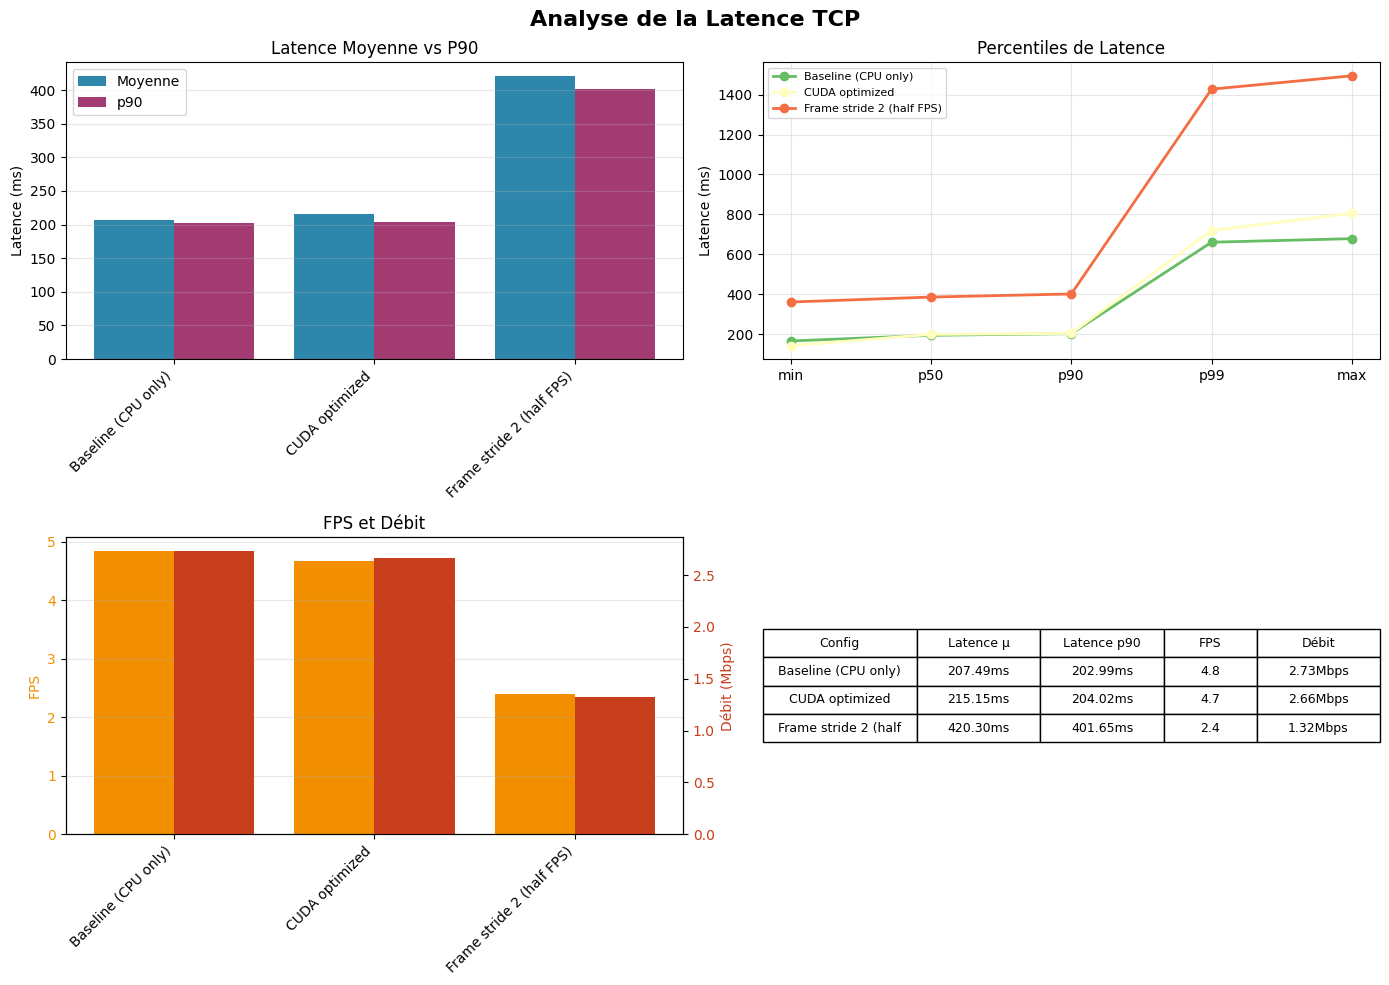

❌ Erreur chargement CSV: No columns to parse from file
❌ Erreur chargement CSV: No columns to parse from file
❌ Erreur chargement CSV: No columns to parse from file
📁 16 fichiers CSV disponibles:

   1. metrics_0_20260112_184233.csv
   2. metrics_0_20260112_184456.csv
   3. metrics_0_20260112_185007.csv
   4. metrics_0_20260112_192550.csv
   5. metrics_0_20260112_200127.csv
   6. metrics_1_20260112_184613.csv
   7. metrics_1_20260112_185122.csv
   8. metrics_1_20260112_192705.csv
   9. metrics_1_20260112_200242.csv
   10. metrics_2_20260112_184728.csv
   11. metrics_2_20260112_185238.csv
   12. metrics_2_20260112_192820.csv
   13. metrics_2_20260112_200357.csv
   14. metrics_3_20260112_185255.csv
   15. metrics_3_20260112_192838.csv
   16. metrics_3_20260112_200414.csv


Socket exception: Une connexion existante a dû être fermée par l’hôte distant (10054)
Socket exception: Une connexion existante a dû être fermée par l’hôte distant (10054)
Socket exception: Une connexion existante a dû être fermée par l’hôte distant (10054)


In [ ]:
# Après avoir lancé les benchmarks, visualisez les résultats ici

# Visualiser UN benchmark (si vous avez lancé l'OPTION 1 ou 3)
# Décommentez les lignes suivantes :
# if 'result' in locals() and result:
#     plot_server_metrics(result['csv_file'], result['config']['name'])

# Visualiser TOUS les benchmarks (si vous avez lancé l'OPTION 2)
# Décommentez les lignes suivantes :
if 'results' in locals() and results:
    # 1. Analyse des latences TCP
    tcp_metrics = [r['tcp_metrics'] for r in results]
    config_names = [r['config']['name'] for r in results]
    plot_latency_analysis(tcp_metrics, config_names)
    
    # 2. Métriques serveur pour chaque config
    for r in results:
        if r['csv_file']:
            plot_server_metrics(r['csv_file'], r['config']['name'])

# Visualiser des benchmarks existants
# Lister les fichiers CSV disponibles :
csv_files = sorted(METRICS_DIR.glob("*.csv"))
if csv_files:
    print(f"{len(csv_files)} fichiers CSV disponibles:\n")
    for i, f in enumerate(csv_files, 1):
        print(f"   {i}. {f.name}")
    
    # Pour visualiser un fichier spécifique, décommentez :
    # plot_server_metrics(str(csv_files[0]), csv_files[0].stem)
else:
    print("Aucun fichier CSV trouvé. Lancez un benchmark d'abord !")